# Stochastic Gradient Descent (SGD)

- RM algorithm is used to find the root of a function or an expression
- SGD is an algorithm for minimizing an objective function
- Suppose we want to minimize an objective function $J(w)$
  
$\begin{align}
&& \min_w J(w) = E[f(w, X)]
\end{align}$

where, 
- $w$ = parameter to be minimize
- $J(w)$ = an objective function i.e., $E[f(w, X)]$
- $X$ is a random variable; The expectation $E$ is with respect to X 
- $w$ and $X$ can be either scalar or vector 

## Method 1: Gradient Descent (SGD)
$\begin{aligned}
    w_{k+1} &= w_k - \alpha_k \, \nabla_w J(w_k) \\
            &= w_k - \alpha_k \, \nabla_w \mathbb{E}[f(w, X)] \\
            &= w_k - \alpha_k \, \mathbb{E}[\nabla_w f(w, X)]
\end{aligned}$


- Drawback: The expected value is difficult to obtain

## Method 2: Batch Gradient Descent (BGD)
- $\begin{aligned}
\mathbb{E}[\nabla_w f(w, X)] \approx 1/n \sum_{i=1}^{n} \nabla_w f(w, x_i)
\end{aligned}$

- The larger the n, the closer the approximation will be.

- $\begin{aligned}
    w_{k+1} &= w_k - \alpha_k  \mathbb{E}[\nabla_w f(w_k, X)]\\
            &\approx  w_k - \alpha_k  \frac{1}{n} \sum_{i=1}^{n} \nabla_w f(w_k, x_i)
\end{aligned}$

- Drawback: It requires many samples in each iteration for each $w_k$

## Method 3: Stochastic Gradient Descent (SGD)
$\begin{aligned}
w_{k+1} = w_k - \alpha_k \nabla_w f(w_k, x_i)
\end{aligned}$

Now, let's implement SGD and BGD algorithm 

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt

In [21]:
def parabola(w):
    return (w - 3)**2

def grad_parabola(w):
    return 2*(w-3)
    
def noisy_grad_parabola(w, sigma=0.5):
    noise = np.random.normal(0, sigma)
    return grad_parabola(w) + noise

In [22]:
def plot_graph(x, y):
    plt.figure(figsize=(8,5))
    plt.plot(x, y, marker='o', linestyle='-', alpha=0.7, markersize=3)
    plt.title("Noisy Parabola")
    plt.xlabel("w")
    plt.ylabel("J(w)")
    plt.grid(True)
    plt.show()

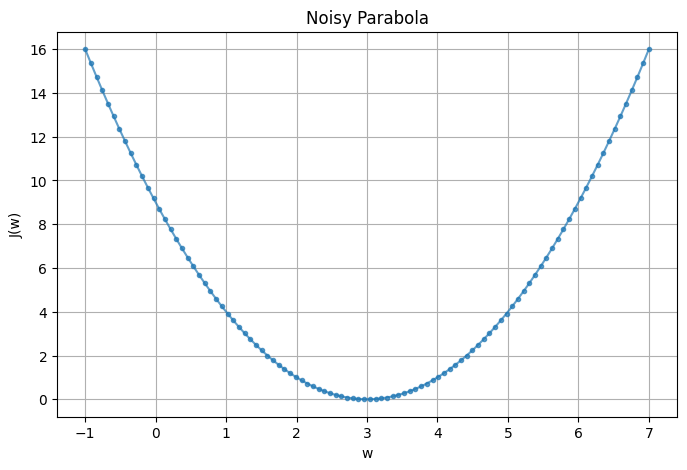

In [23]:
w_range  = [-1, 7]
num_points = 100
w_values = np.linspace(w_range[0], w_range[1], num_points)
y_values = [parabola(w) for w in w_values]
plot_graph(w_values, y_values)

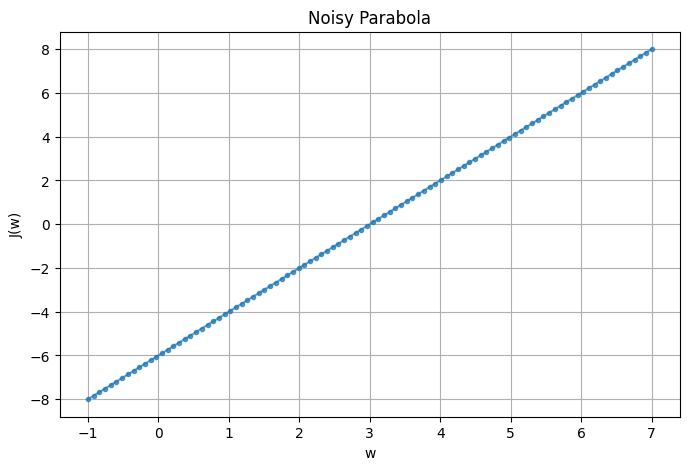

In [24]:
w_range  = [-1, 7]
num_points = 100
w_values = np.linspace(w_range[0], w_range[1], num_points)
y_values = [grad_parabola(w) for w in w_values]
plot_graph(w_values, y_values)

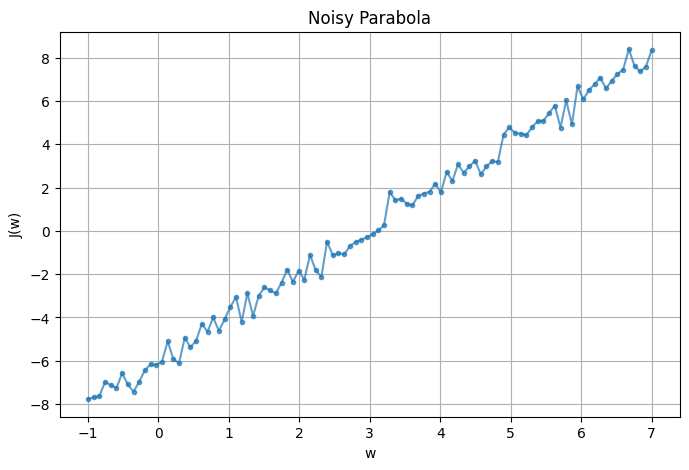

In [26]:
w_range  = [-1, 7]
num_points = 100
w_values = np.linspace(w_range[0], w_range[1], num_points)
y_values = [noisy_grad_parabola(w) for w in w_values]
plot_graph(w_values, y_values)

In [95]:
def sgd_algorithm(noisy_grad_j_func, n_steps, alpha=0.01):
    w = 0
    w_history = []
    for k in range(1, n_steps):
        x = np.random.randint(-1, high=7, dtype='int').item()
        
        if alpha:
            alpha_k = alpha
        else:
            alpha_k = 1/k
        
        w = w - alpha_k * noisy_grad_j_func(w, )
        w_history.append(w)
    return w, w_history


def batch_sgd_algorithm(noisy_grad_j_func, batch_size=64, n_steps=100, alpha=0.01):
    w = 0
    w_history = []
    
    batch_x = np.random.randint(-1, high=7, size=batch_size, dtype='int').item()
    for k in range(1, n_steps):
        
        if alpha:
            alpha_k = alpha
        else:
            alpha_k = 1/k

        batch_grad_sum = sum([noisy_grad_j_func(w, x) for x in batch_x])
        w = w - alpha_k * 1/batch_size * batch_grad_sum
        w_history.append(w)
    return w, w_history

In [96]:
w, w_history = sgd_algorithm(noisy_grad_parabola, 600)
w

2.990312468965785

In [100]:
w_b, w_b_history = sgd_algorithm(noisy_grad_parabola, 200, alpha=None)
w_b

2.992418348298853

# Plot history

In [101]:
def plot_line_graph(y_values, x_start=0, x_step=1, title="Line Plot", xlabel="iteration", ylabel="mean"):
    x_values = np.arange(
        x_start,
        x_start + x_step * len(y_values),
        x_step
    )
    plt.figure(figsize=(16, 4))
    plt.plot(x_values, y_values, marker='o', markersize=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

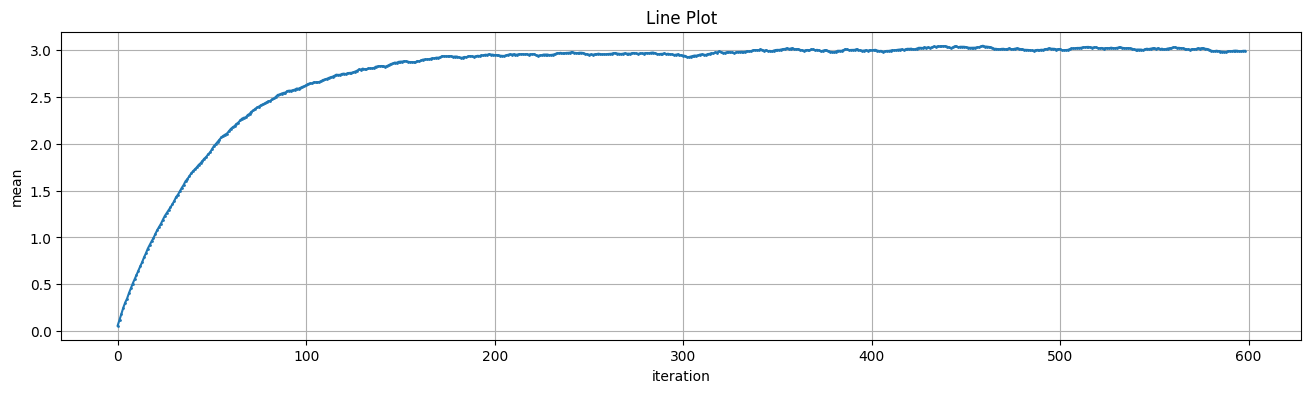

In [102]:
plot_line_graph(w_history)

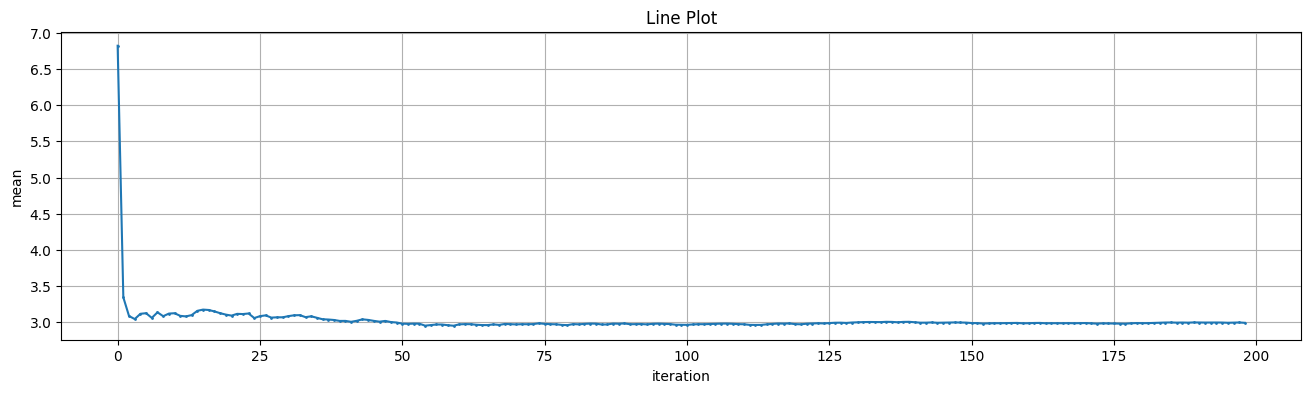

In [103]:
plot_line_graph(w_b_history)